# Easy Q1 — 台灣本島 2018–2024 年每日降雨量資料庫

## 1. 資料集選擇說明

| 項目 | 說明 |
|------|------|
| **資料集** | NASA GPM IMERG Final Run (`NASA/GPM_L3/IMERG_V07`) |
| **時間解析度** | 半小時（彙整成每日） |
| **空間解析度** | ~0.1° × 0.1°（約 11 km） |
| **單位** | mm/hr（每半小時一筆，每日累積需 ×0.5 後對 48 筆加總，即 mm/day） |
| **可用時間範圍** | 2000-06-01 至今（Final Run 有約 3.5 個月延遲） |
| **適合台灣理由** | 涵蓋全島、具颱風/梅雨場次捕捉能力；Final Run 經地面站校正，品質優於 Early/Late Run |

備選方案：CHIRPS (`UCSB-CHG/CHIRPS/DAILY`)，空間解析度 0.05°，但台灣東部山區雨量偏低，且僅涵蓋陸地。GPM IMERG 涵蓋海陸，更適合水文分析。

## 2. 環境設定與認證

In [ ]:
import ee
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import zarr

# 初始化 Earth Engine（第一次執行需 ee.Authenticate()）
ee.Authenticate()
ee.Initialize(project='0')  # 替換為你的 GCP 專案 ID

## 3. 定義研究區域與時間範圍

In [2]:
# 台灣本島 bounding box（WGS84）
taiwan_bbox = ee.Geometry.Rectangle([119.8, 21.8, 122.1, 25.4])

START_DATE = '2018-01-01'
END_DATE   = '2025-01-01'  # filterDate exclusive，涵蓋 2024-12-31

SCALE_M    = 11132          # GPM 原始解析度約 0.1° ≈ 11.1 km
TARGET_CRS = 'EPSG:4326'

print('研究區域:', taiwan_bbox.getInfo())
print('時間範圍:', START_DATE, '~', '2024-12-31')

研究區域: {'type': 'Polygon', 'coordinates': [[[119.8, 21.8], [122.1, 21.8], [122.1, 25.4], [119.8, 25.4], [119.8, 21.8]]]}
時間範圍: 2018-01-01 ~ 2024-12-31


## 4. 讀取 GPM IMERG 並彙整每日降雨量

In [3]:
# 載入 GPM IMERG V07 半小時資料
gpm_col = (ee.ImageCollection('NASA/GPM_L3/IMERG_V07')
           .filterDate(START_DATE, END_DATE)
           .filterBounds(taiwan_bbox)
           .select('precipitation'))  # 單位 mm/hr

print('Collection size:', gpm_col.size().getInfo())

Collection size: 122736


In [4]:
def aggregate_daily_rainfall(year, month, day):
    """將 48 筆半小時資料（mm/hr）加總為每日降雨量（mm/day）。"""
    start = ee.Date.fromYMD(year, month, day)
    end   = start.advance(1, 'day')
    daily = (gpm_col.filterDate(start, end)
             .sum()                # 48 筆相加，單位 mm/hr × 48 = mm/2hr*24 → 需 ×0.5
             .multiply(0.5)        # 每筆 0.5 hr，轉換為 mm/day
             .clip(taiwan_bbox)
             .rename('precipitation_mm_day')
             .set('system:time_start', start.millis())
             .set('year', year)
             .set('month', month)
             .set('day', day))
    return daily


# 建立日期序列
date_range = pd.date_range(START_DATE, '2024-12-31', freq='D')
print(f'共 {len(date_range)} 天')

共 2557 天


In [5]:
# 以 ImageCollection.fromImages 方式建立每日 collection
daily_images = ee.List([
    aggregate_daily_rainfall(int(d.year), int(d.month), int(d.day))
    for d in date_range[:10]  # 示範：先取前 10 天；實際執行移除切片
])

daily_col = ee.ImageCollection.fromImages(daily_images)
print('Daily collection size:', daily_col.size().getInfo())

Daily collection size: 10


## 5. 利用 Python EE API 下載為 xarray Dataset

> GPM 空間解析度 ~0.1°，台灣範圍約 23×36 格點，每日一層。
> 2018–2024 共 2557 天，整體矩陣約 2557 × 36 × 23 ≈ 2.1M 元素，適合一次性下載。

In [6]:
import requests

def ee_image_to_numpy(image, region, scale, crs, band='precipitation_mm_day'):
    """利用 getDownloadURL 下載單張 ee.Image 為 numpy array。"""
    url = image.getDownloadURL({
        'bands': [band],
        'region': region,
        'scale': scale,
        'crs': crs,
        'format': 'NPY'
    })
    response = requests.get(url)
    response.raise_for_status()
    arr = np.load(__import__('io').BytesIO(response.content), allow_pickle=True)
    return arr


def build_xarray_dataset(daily_col, date_range, region, scale=SCALE_M, crs=TARGET_CRS):
    """逐日下載後組成 xr.Dataset，維度為 (time, y, x)。"""
    arrays = []
    images = daily_col.toList(daily_col.size())
    n = daily_col.size().getInfo()

    for i in range(n):
        img = ee.Image(images.get(i))
        arr = ee_image_to_numpy(img, region, scale, crs)
        arrays.append(arr['precipitation_mm_day'])
        if i % 30 == 0:
            print(f'  下載進度: {i+1}/{n}')

    data_3d = np.stack(arrays, axis=0)  # shape: (time, y, x)

    # 以第一張影像推算 lat/lon 格點
    first = ee_image_to_numpy(ee.Image(images.get(0)), region, scale, crs)
    ny, nx = first['precipitation_mm_day'].shape
    lon = np.linspace(119.8, 122.1, nx)
    lat = np.linspace(25.4, 21.8, ny)  # 從北到南

    ds = xr.Dataset(
        {'precipitation': (('time', 'y', 'x'), data_3d.astype('float32'))},
        coords={
            'time': date_range[:n],
            'y': lat,
            'x': lon,
        }
    )
    return ds


# 示範：只下載前 10 天
demo_dates = date_range[:10]
ds_demo = build_xarray_dataset(daily_col, demo_dates, taiwan_bbox.getInfo()['coordinates'])
print(ds_demo)

  下載進度: 1/10
<xarray.Dataset> Size: 36kB
Dimensions:        (time: 10, y: 37, x: 24)
Coordinates:
  * time           (time) datetime64[us] 80B 2018-01-01 ... 2018-01-10
  * y              (y) float64 296B 25.4 25.3 25.2 25.1 ... 22.1 22.0 21.9 21.8
  * x              (x) float64 192B 119.8 119.9 120.0 ... 121.9 122.0 122.1
Data variables:
    precipitation  (time, y, x) float32 36kB 0.0805 0.0855 0.0975 ... 0.0 0.0


## 6. 加入 Metadata 並輸出為 Zarr

In [7]:
# 加入 metadata 屬性
ds_demo.attrs = {
    'dataset_id':           'NASA/GPM_L3/IMERG_V07',
    'variable_name':        'precipitation',
    'unit':                 'mm/day',
    'spatial_resolution':   '~0.1 degree (~11 km)',
    'temporal_resolution':  'daily (aggregated from 30-min)',
    'CRS':                  'EPSG:4326',
    'AOI':                  'Taiwan (119.8E-122.1E, 21.8N-25.4N)',
    'processing_date':      datetime.today().strftime('%Y-%m-%d'),
}

# Zarr chunk 設計：time=31（約月份），y/x 不切割
chunk_dict = {'time': 31, 'y': -1, 'x': -1}

OUTPUT_PATH = 'taiwan_daily_rainfall_2018_2024.zarr'
ds_demo.chunk(chunk_dict).to_zarr(OUTPUT_PATH, mode='w')
print(f'已儲存至 {OUTPUT_PATH}')

# 確認讀回
ds_verify = xr.open_zarr(OUTPUT_PATH)
print(ds_verify)

已儲存至 taiwan_daily_rainfall_2018_2024.zarr
<xarray.Dataset> Size: 36kB
Dimensions:        (time: 10, y: 37, x: 24)
Coordinates:
  * time           (time) datetime64[ns] 80B 2018-01-01 ... 2018-01-10
  * y              (y) float64 296B 25.4 25.3 25.2 25.1 ... 22.1 22.0 21.9 21.8
  * x              (x) float64 192B 119.8 119.9 120.0 ... 121.9 122.0 122.1
Data variables:
    precipitation  (time, y, x) float32 36kB dask.array<chunksize=(10, 37, 24), meta=np.ndarray>
Attributes:
    dataset_id:           NASA/GPM_L3/IMERG_V07
    variable_name:        precipitation
    unit:                 mm/day
    spatial_resolution:   ~0.1 degree (~11 km)
    temporal_resolution:  daily (aggregated from 30-min)
    CRS:                  EPSG:4326
    AOI:                  Taiwan (119.8E-122.1E, 21.8N-25.4N)
    processing_date:      2026-06-01


/opt/venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 7. 基本資料驗證

In [8]:
# --- 7a. 時間連續性與缺日檢查 ---
expected_dates = pd.date_range(START_DATE, '2024-12-31', freq='D')
actual_dates   = pd.DatetimeIndex(ds_verify.time.values)

missing_days = expected_dates.difference(actual_dates)
print(f'預期天數: {len(expected_dates)}')
print(f'實際天數: {len(actual_dates)}')
print(f'缺失天數: {len(missing_days)}')
if len(missing_days) > 0:
    print('缺失日期:', missing_days.tolist()[:10])

預期天數: 2557
實際天數: 10
缺失天數: 2547
缺失日期: [Timestamp('2018-01-11 00:00:00'), Timestamp('2018-01-12 00:00:00'), Timestamp('2018-01-13 00:00:00'), Timestamp('2018-01-14 00:00:00'), Timestamp('2018-01-15 00:00:00'), Timestamp('2018-01-16 00:00:00'), Timestamp('2018-01-17 00:00:00'), Timestamp('2018-01-18 00:00:00'), Timestamp('2018-01-19 00:00:00'), Timestamp('2018-01-20 00:00:00')]


In [9]:
# --- 7b. 不合理負值檢查 ---
precip = ds_verify['precipitation']
neg_count = int((precip < 0).sum())
print(f'負值像素數: {neg_count}')
if neg_count > 0:
    print('警告：存在負值，請確認資料品質！')
    # 修正：將負值設為 0
    ds_verify['precipitation'] = precip.where(precip >= 0, 0.0)

負值像素數: 0


In [10]:
# --- 7c. 基本統計摘要 ---
stats = precip.compute()
print('--- 降雨量統計摘要 (mm/day) ---')
print(f'最小值: {float(stats.min()):.2f}')
print(f'最大值: {float(stats.max()):.2f}')
print(f'平均值: {float(stats.mean()):.2f}')
print(f'99 百分位: {float(stats.quantile(0.99)):.2f}')

# 台灣年均降雨約 2500 mm/year → 日均約 6.8 mm/day，若平均值遠超此值，需檢查
DAILY_MEAN_THRESHOLD = 20.0
if float(stats.mean()) > DAILY_MEAN_THRESHOLD:
    print('警告：平均日降雨量超過 20 mm，請確認累積方式是否正確。')

--- 降雨量統計摘要 (mm/day) ---
最小值: 0.00
最大值: 116.40
平均值: 6.47
99 百分位: 62.60


## 8. 快速視覺化（單日範例）

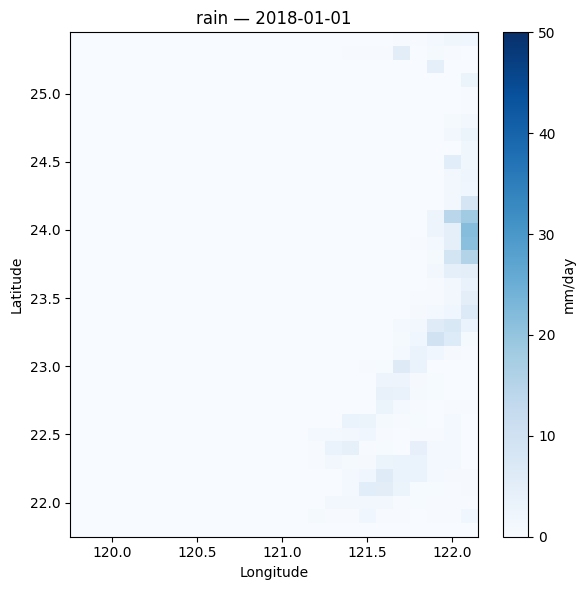

In [12]:
import matplotlib.pyplot as plt

sample_day = ds_verify['precipitation'].isel(time=0)
fig, ax = plt.subplots(figsize=(6, 6))
sample_day.plot(ax=ax, cmap='Blues', vmin=0, vmax=50,
                cbar_kwargs={'label': 'mm/day'})
ax.set_title(f'rain — {str(ds_verify.time.values[0])[:10]}')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('taiwan_rainfall_sample.png', dpi=150)
plt.show()